# 📄 Universal Document Restoration Tool

Restores scanned, aged, stained, faded, or damaged documents to clean black-on-white.

**Supports:** JPEG, PNG, TIFF, BMP, WebP — single files or batch folders.

**Pipeline:**
1. Deskew (straighten tilted scans)
2. Illumination correction (remove shadows, stains, uneven lighting)
3. Adaptive binarization (clean black text on white paper)
4. Noise removal & stroke enhancement
5. **`black_on_white` mode** — exact pipeline used on the meteorological record: background normalisation → histogram stretch → adaptive threshold → median denoise → stroke thicken → hard B&W binarization
6. Optional: enhanced mode (sharpen only, no binarization) for photos/mixed content
7. Output as PNG or PDF

## Step 1 — Install Dependencies

In [1]:
!pip install Pillow scipy numpy opencv-python-headless reportlab ipywidgets tqdm

## Step 2 — Imports & Configuration

In [2]:
import os
import glob
import math
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, List

import numpy as np
import cv2
from PIL import Image, ImageFilter, ImageOps, ImageEnhance
from scipy.ndimage import gaussian_filter, uniform_filter, minimum_filter
from reportlab.lib.pagesizes import A4, letter
from reportlab.pdfgen import canvas as rl_canvas
from reportlab.lib.units import mm
from tqdm import tqdm
from IPython.display import display, HTML, Image as IPImage
import ipywidgets as widgets

print("✅ All imports successful.")

✅ All imports successful.


## Step 3 — Restoration Settings

Edit the `Config` object below to control every aspect of restoration.

In [3]:
@dataclass
class Config:
    # ── Input ─────────────────────────────────────────────────────────────────
    input_path: str = r"C:\Users\Dylanator\Downloads\9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b.jpeg"          # single file OR folder path
    output_dir: str = "restored_output"    # where results are saved

    # ── Mode ──────────────────────────────────────────────────────────────────
    mode: str = "black_on_white"  
    # Options:
    #   "black_on_white" → RECOMMENDED: exact pipeline from the meteorological
    #                      record restoration. Background normalisation,
    #                      adaptive local threshold, median denoise, stroke
    #                      thickening, hard B&W binarization. Best all-rounder
    #                      for aged, stained, or unevenly-lit documents.
    #   "binarize"       → simpler binarize pipeline (faster, less aggressive)
    #   "enhance"        → sharpen + contrast only (photos / mixed content)
    #   "both"           → black_on_white + enhance saved side-by-side

    # ── Output format ─────────────────────────────────────────────────────────
    output_format: str = "png"  # "png", "pdf", or "both"
    upscale_factor: int = 2     # 1 = original size, 2 = 2x, 3 = 3x

    # ── Deskew ────────────────────────────────────────────────────────────────
    deskew: bool = True         # auto-straighten tilted scans
    max_skew_angle: float = 15  # maximum degrees to correct

    # ── Illumination correction ────────────────────────────────────────────────
    correct_illumination: bool = True
    background_sigma: float = 80  # larger = correct broader shadows

    # ── Binarization (mode="binarize") ────────────────────────────────────────
    adaptive_window: int = 60   # local neighbourhood size for thresholding
    binarize_threshold: float = 15  # sensitivity (lower = capture faint ink)
    stroke_thicken: int = 2         # pixel dilation of ink strokes (1-4)
    noise_filter_size: int = 3      # median filter size for speckle removal

    # ── Black-on-White (mode="black_on_white") — meteorological record pipeline ─
    bow_upscale_processing: int = 3  # internal upscale during processing (3 = best quality)
    bow_output_upscale: int = 2      # final output upscale relative to original
    bow_bg_sigma: float = 80         # gaussian sigma for background estimation
                                     # higher = corrects broader stains/shadows
    bow_adaptive_window: int = 60    # local mean window for ink detection
    bow_threshold: float = 15        # ink sensitivity (lower = finer/faded ink)
    bow_noise_size: int = 3          # median filter kernel (speckle removal)
    bow_stroke_size: int = 2         # minimum_filter size (stroke thickening)
    bow_final_threshold: int = 180   # hard B&W cutoff (0-255, lower = more black)

    # ── Enhance mode (mode="enhance") ─────────────────────────────────────────
    contrast_factor: float = 3.0    # 1.0 = unchanged, 3.0 = strong boost
    brightness_factor: float = 1.3
    sharpen_passes: int = 2         # number of sharpening passes
    unsharp_radius: float = 2.0
    unsharp_percent: int = 200

    # ── PDF output options ─────────────────────────────────────────────────────
    pdf_page_size: str = "A4"       # "A4" or "letter"
    pdf_fit_page: bool = True       # scale image to fit page

# ── Instantiate — edit values here ───────────────────────────────────────────
cfg = Config(
    input_path   = r"C:\Users\Dylanator\Downloads\9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b.jpeg",           # ← change to your file or folder
    output_dir   = "restored_output",
    mode         = "black_on_white",      # "black_on_white" | "binarize" | "enhance" | "both"
    output_format= "png",                 # "png" | "pdf" | "both"
    upscale_factor = 2,
    deskew       = True,
)

print("⚙️  Config loaded:")
for k, v in cfg.__dict__.items():
    print(f"   {k:30s} = {v}")

⚙️  Config loaded:
   input_path                     = C:\Users\Dylanator\Downloads\9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b.jpeg
   output_dir                     = restored_output
   mode                           = black_on_white
   output_format                  = png
   upscale_factor                 = 2
   deskew                         = True
   max_skew_angle                 = 15
   correct_illumination           = True
   background_sigma               = 80
   adaptive_window                = 60
   binarize_threshold             = 15
   stroke_thicken                 = 2
   noise_filter_size              = 3
   bow_upscale_processing         = 3
   bow_output_upscale             = 2
   bow_bg_sigma                   = 80
   bow_adaptive_window            = 60
   bow_threshold                  = 15
   bow_noise_size                 = 3
   bow_stroke_size                = 2
   bow_final_threshold            = 180
   contrast_factor                = 3.0
   brightness_factor          

## Step 4 — Core Restoration Functions

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# DESKEW
# ─────────────────────────────────────────────────────────────────────────────
def detect_skew_angle(img_gray: np.ndarray, max_angle: float = 15.0) -> float:
    """
    Detect the skew angle of a document image using Hough line transform.
    Returns angle in degrees (positive = clockwise tilt).
    """
    # Edge detection
    edges = cv2.Canny(img_gray, 50, 150, apertureSize=3)
    
    # Probabilistic Hough lines
    lines = cv2.HoughLinesP(
        edges, 1, np.pi / 180,
        threshold=100,
        minLineLength=img_gray.shape[1] // 4,
        maxLineGap=20
    )
    if lines is None:
        return 0.0

    angles = []
    for x1, y1, x2, y2 in lines[:, 0]:
        if x2 != x1:
            angle = math.degrees(math.atan2(y2 - y1, x2 - x1))
            if abs(angle) < max_angle:
                angles.append(angle)

    if not angles:
        return 0.0
    return float(np.median(angles))


def deskew(pil_img: Image.Image, max_angle: float = 15.0) -> Image.Image:
    """
    Detect and correct document skew. Returns deskewed PIL image.
    """
    gray = np.array(pil_img.convert("L"))
    angle = detect_skew_angle(gray, max_angle)
    if abs(angle) < 0.1:
        return pil_img  # nothing to do
    print(f"   ↩  Correcting skew: {angle:.2f}°")
    return pil_img.rotate(-angle, resample=Image.BICUBIC, expand=True, fillcolor=255)


# ─────────────────────────────────────────────────────────────────────────────
# BINARIZE PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def restore_binarize(pil_img: Image.Image, cfg: Config) -> Image.Image:
    """
    Full binarization pipeline:
      illumination correction → adaptive threshold → noise removal → stroke thicken
    Returns clean black-on-white PIL image.
    """
    img = pil_img.convert("L")
    w, h = img.size

    # Upscale
    if cfg.upscale_factor > 1:
        img = img.resize((w * cfg.upscale_factor, h * cfg.upscale_factor), Image.LANCZOS)

    arr = np.array(img, dtype=np.float32)

    # 1. Illumination correction
    if cfg.correct_illumination:
        background = gaussian_filter(arr, sigma=cfg.background_sigma)
        arr = arr / (background + 1e-6) * 200.0
        arr = np.clip(arr, 0, 255)

    # 2. Histogram stretch
    p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
    arr = (arr - p2) / (p98 - p2 + 1e-6) * 255.0
    arr = np.clip(arr, 0, 255)

    # 3. Adaptive local threshold
    local_mean = uniform_filter(arr, size=cfg.adaptive_window)
    diff = local_mean - arr
    binary = np.where(diff > cfg.binarize_threshold, 0.0, 255.0)

    # 4. Speckle noise removal
    result = Image.fromarray(binary.astype(np.uint8))
    if cfg.noise_filter_size > 1:
        result = result.filter(ImageFilter.MedianFilter(size=cfg.noise_filter_size))

    # 5. Stroke thickening
    if cfg.stroke_thicken > 1:
        a = np.array(result, dtype=np.float32)
        a = minimum_filter(a, size=cfg.stroke_thicken)
        result = Image.fromarray(a.astype(np.uint8))

    # 6. Auto-contrast
    result = ImageOps.autocontrast(result, cutoff=1)

    # 7. Downscale to 2x output, hard threshold
    out_w, out_h = w * min(cfg.upscale_factor, 2), h * min(cfg.upscale_factor, 2)
    result = result.resize((out_w, out_h), Image.LANCZOS)
    out_arr = np.array(result)
    out_arr = np.where(out_arr < 180, 0, 255).astype(np.uint8)

    return Image.fromarray(out_arr)


# ─────────────────────────────────────────────────────────────────────────────
# BLACK-ON-WHITE PIPELINE  (exact method used on the meteorological record)
# ─────────────────────────────────────────────────────────────────────────────
def restore_black_on_white(pil_img: Image.Image, cfg: Config) -> Image.Image:
    """
    Restores a document to clean black type on white paper.

    This is the exact pipeline applied to the British West African
    Meteorological Services record, proven on heavily aged, stained,
    and unevenly-lit documents.

    Steps
    -----
    1. Grayscale conversion
    2. 3× upscale for high-res processing
    3. Background illumination correction via large Gaussian blur
    4. Percentile histogram stretch (2nd–98th)
    5. Adaptive local thresholding (uniform_filter mean vs. pixel)
    6. Median filter — speckle / noise removal
    7. minimum_filter — slight stroke thickening for legibility
    8. Auto-contrast
    9. Downscale to 2× output, hard binary threshold at bow_final_threshold
    """
    img = pil_img.convert("L")
    w, h = img.size

    # ── 1. Upscale for higher-resolution processing ───────────────────────────
    proc_w = w * cfg.bow_upscale_processing
    proc_h = h * cfg.bow_upscale_processing
    img = img.resize((proc_w, proc_h), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32)

    # ── 2. Background illumination correction ─────────────────────────────────
    # Estimate page background using a large Gaussian blur, then normalise.
    # This removes uneven lighting, stains, and age-related discolouration.
    background = gaussian_filter(arr, sigma=cfg.bow_bg_sigma)
    corrected  = arr / (background + 1e-6) * 200.0
    corrected  = np.clip(corrected, 0, 255)

    # ── 3. Percentile histogram stretch ──────────────────────────────────────
    p2  = np.percentile(corrected, 2)
    p98 = np.percentile(corrected, 98)
    stretched = (corrected - p2) / (p98 - p2 + 1e-6) * 255.0
    stretched = np.clip(stretched, 0, 255)

    # ── 4. Adaptive local thresholding ────────────────────────────────────────
    # Pixels significantly darker than their local neighbourhood = ink.
    local_mean = uniform_filter(stretched, size=cfg.bow_adaptive_window)
    diff       = local_mean - stretched
    binary     = np.where(diff > cfg.bow_threshold, 0.0, 255.0)  # 0=black, 255=white

    # ── 5. Speckle / noise removal ────────────────────────────────────────────
    result = Image.fromarray(binary.astype(np.uint8))
    result = result.filter(ImageFilter.MedianFilter(size=cfg.bow_noise_size))

    # ── 6. Stroke thickening ──────────────────────────────────────────────────
    # minimum_filter darkens (expands) black ink pixels slightly so thin
    # strokes and faint handwriting remain readable after hard thresholding.
    a = np.array(result, dtype=np.float32)
    a = minimum_filter(a, size=cfg.bow_stroke_size)
    result = Image.fromarray(a.astype(np.uint8))

    # ── 7. Auto-contrast ──────────────────────────────────────────────────────
    result = ImageOps.autocontrast(result, cutoff=1)

    # ── 8. Downscale to output size, hard binary threshold ────────────────────
    out_w = w * cfg.bow_output_upscale
    out_h = h * cfg.bow_output_upscale
    result  = result.resize((out_w, out_h), Image.LANCZOS)
    out_arr = np.array(result)
    out_arr = np.where(out_arr < cfg.bow_final_threshold, 0, 255).astype(np.uint8)

    return Image.fromarray(out_arr)


# ─────────────────────────────────────────────────────────────────────────────
# ENHANCE PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
def restore_enhance(pil_img: Image.Image, cfg: Config) -> Image.Image:
    """
    Sharpen + contrast boost pipeline (no binarization).
    Best for photos, mixed-content pages, or colour documents.
    Returns enhanced colour PIL image.
    """
    img = pil_img.convert("L")
    w, h = img.size

    if cfg.upscale_factor > 1:
        img = img.resize((w * cfg.upscale_factor, h * cfg.upscale_factor), Image.LANCZOS)

    img = img.filter(ImageFilter.UnsharpMask(
        radius=cfg.unsharp_radius,
        percent=cfg.unsharp_percent,
        threshold=3
    ))
    img = ImageEnhance.Contrast(img).enhance(cfg.contrast_factor)
    img = ImageEnhance.Brightness(img).enhance(cfg.brightness_factor)

    for _ in range(cfg.sharpen_passes):
        img = img.filter(ImageFilter.SHARPEN)

    img = ImageOps.autocontrast(img, cutoff=2)
    img = img.filter(ImageFilter.UnsharpMask(radius=1, percent=150, threshold=2))

    return img


# ─────────────────────────────────────────────────────────────────────────────
# SAVE AS PDF
# ─────────────────────────────────────────────────────────────────────────────
def save_as_pdf(pil_img: Image.Image, pdf_path: str, cfg: Config):
    """
    Embed a PIL image into a single-page PDF using ReportLab.
    """
    page_size = A4 if cfg.pdf_page_size == "A4" else letter
    pw, ph = page_size

    # Save image to temp PNG
    tmp_png = pdf_path.replace(".pdf", "_tmp.png")
    pil_img.save(tmp_png, "PNG")

    c = rl_canvas.Canvas(pdf_path, pagesize=page_size)

    if cfg.pdf_fit_page:
        iw, ih = pil_img.size
        scale = min(pw / iw, ph / ih) * 0.95   # 5% margin
        dw, dh = iw * scale, ih * scale
        x = (pw - dw) / 2
        y = (ph - dh) / 2
        c.drawImage(tmp_png, x, y, width=dw, height=dh)
    else:
        c.drawImage(tmp_png, 0, 0, width=pw, height=ph)

    c.save()
    os.remove(tmp_png)


print("✅ Core functions defined.")

✅ Core functions defined.


## Step 5 — Main Restore Function

In [5]:
SUPPORTED_EXT = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp", ".webp"}


def get_input_files(input_path: str) -> List[Path]:
    """Return list of image files from a path (file or directory)."""
    p = Path(input_path)
    if p.is_file():
        return [p]
    elif p.is_dir():
        files = [f for f in p.iterdir() if f.suffix.lower() in SUPPORTED_EXT]
        files.sort()
        return files
    else:
        raise FileNotFoundError(f"Input not found: {input_path}")


def restore_document(image_path: str | Path, cfg: Config) -> dict:
    """
    Restore a single document image.
    Returns dict with output paths and PIL images for preview.
    """
    image_path = Path(image_path)
    print(f"\n📄 Processing: {image_path.name}")

    out_dir = Path(cfg.output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Load
    original = Image.open(image_path)
    print(f"   📐 Original size: {original.size[0]}×{original.size[1]} px")

    # Deskew
    if cfg.deskew:
        original = deskew(original, cfg.max_skew_angle)

    results = {}
    stem = image_path.stem

    def _save(img, suffix):
        paths = {}
        if cfg.output_format in ("png", "both"):
            p = out_dir / f"{stem}{suffix}.png"
            img.save(str(p), "PNG")
            paths["png"] = str(p)
            print(f"   💾 Saved PNG → {p}")
        if cfg.output_format in ("pdf", "both"):
            p = out_dir / f"{stem}{suffix}.pdf"
            save_as_pdf(img, str(p), cfg)
            paths["pdf"] = str(p)
            print(f"   💾 Saved PDF → {p}")
        return paths

    if cfg.mode in ("binarize", "both"):
        print("   🔲 Running binarize pipeline...")
        bw = restore_binarize(original, cfg)
        results["binarize"] = {"image": bw, **_save(bw, "_binarized")}
        print(f"   ✅ Binarized: {bw.size[0]}×{bw.size[1]} px")

    if cfg.mode in ("black_on_white", "both"):
        print("   ⬛ Running black-on-white pipeline (meteorological record method)...")
        bow = restore_black_on_white(original, cfg)
        results["black_on_white"] = {"image": bow, **_save(bow, "_black_on_white")}
        print(f"   ✅ Black-on-white: {bow.size[0]}×{bow.size[1]} px")

    if cfg.mode in ("enhance", "both"):
        print("   🔆 Running enhance pipeline...")
        enh = restore_enhance(original, cfg)
        results["enhance"] = {"image": enh, **_save(enh, "_enhanced")}
        print(f"   ✅ Enhanced: {enh.size[0]}×{enh.size[1]} px")

    return results


def restore_all(cfg: Config) -> List[dict]:
    """
    Restore all documents found at cfg.input_path.
    Returns list of result dicts.
    """
    files = get_input_files(cfg.input_path)
    print(f"\n🗂️  Found {len(files)} file(s) to process.")

    all_results = []
    for f in tqdm(files, desc="Restoring"):
        try:
            r = restore_document(f, cfg)
            r["source"] = str(f)
            all_results.append(r)
        except Exception as e:
            print(f"   ⚠️  Error processing {f.name}: {e}")

    print(f"\n✅ Done. {len(all_results)}/{len(files)} file(s) restored → '{cfg.output_dir}/'")
    return all_results


print("✅ Main restore function defined.")

✅ Main restore function defined.


## Step 6 — Interactive Preview Widget
Run this cell to get a side-by-side preview of original vs. restored.

In [6]:
import io, base64

def pil_to_b64(img: Image.Image, max_width=500) -> str:
    """Convert PIL image to base64 PNG string for HTML display."""
    w, h = img.size
    if w > max_width:
        img = img.resize((max_width, int(h * max_width / w)), Image.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()


def preview_result(original_path: str, result: dict):
    """
    Display a side-by-side HTML comparison of original vs. restored image(s).
    """
    orig = Image.open(original_path)
    orig_b64 = pil_to_b64(orig)

    panels = f"""
    <div style="display:flex; gap:16px; flex-wrap:wrap; font-family:'Courier New',monospace;">
      <div style="text-align:center">
        <p style="font-weight:bold; margin:4px 0;">📷 Original</p>
        <img src="data:image/png;base64,{orig_b64}" style="max-width:480px; border:1px solid #ccc;">
        <p style="color:#666; font-size:11px;">{orig.size[0]}×{orig.size[1]} px</p>
      </div>
    """

    for mode_key, label in [("black_on_white", "⬛ Black-on-White"), ("binarize", "🔲 Binarized"), ("enhance", "🔆 Enhanced")]:
        if mode_key in result:
            img = result[mode_key]["image"]
            b64 = pil_to_b64(img)
            panels += f"""
      <div style="text-align:center">
        <p style="font-weight:bold; margin:4px 0;">{label}</p>
        <img src="data:image/png;base64,{b64}" style="max-width:480px; border:1px solid #333;">
        <p style="color:#666; font-size:11px;">{img.size[0]}×{img.size[1]} px</p>
      </div>
            """

    panels += "</div>"
    display(HTML(panels))


print("✅ Preview widget ready.")

✅ Preview widget ready.


## Step 7 — Run the Restoration

Make sure `cfg.input_path` points to your file or folder, then run this cell.

In [7]:
# ── Edit these if needed ──────────────────────────────────────────────────────
cfg.input_path    = r"C:\Users\Dylanator\Downloads\9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b.jpeg"          # ← file or folder
cfg.output_dir    = "restored_output"
cfg.mode          = "black_on_white"     # "black_on_white" | "binarize" | "enhance" | "both"
cfg.output_format = "png"                # "png" | "pdf" | "both"
cfg.upscale_factor = 2
cfg.deskew        = True
# ─────────────────────────────────────────────────────────────────────────────

results = restore_all(cfg)


🗂️  Found 1 file(s) to process.


Restoring:   0%|                                                                                 | 0/1 [00:00<?, ?it/s]


📄 Processing: 9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b.jpeg
   📐 Original size: 872×670 px
   ⬛ Running black-on-white pipeline (meteorological record method)...


Restoring: 100%|█████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.42s/it]

   💾 Saved PNG → restored_output\9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b_black_on_white.png
   ✅ Black-on-white: 1744×1340 px

✅ Done. 1/1 file(s) restored → 'restored_output/'


## Step 8 — Preview Results


────────────────────────────────────────────────────────────
Source: C:\Users\Dylanator\Downloads\9e0c8b84-69c2-47a0-adbe-6e91b2f77d4b.jpeg



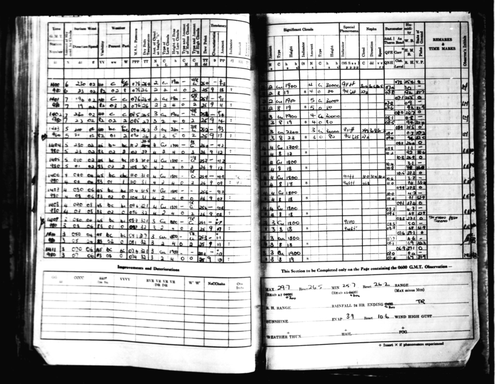
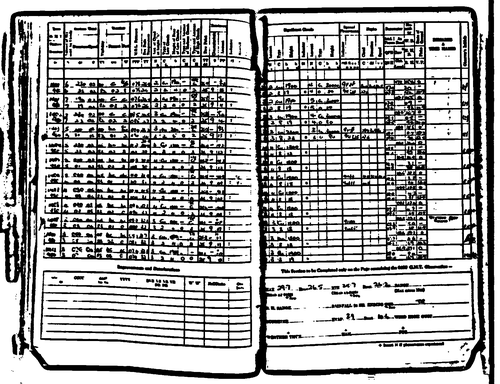

In [8]:
for r in results:
    print(f"\n{'─'*60}")
    print(f"Source: {r['source']}")
    preview_result(r["source"], r)

---
## Appendix — Quick Presets

Copy any preset into **Step 7** to override the default config for common use cases.

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PRESET E — Black-on-white: standard (matches meteorological record exactly)
# ══════════════════════════════════════════════════════════════════════════════
preset_bow_standard = Config(
    input_path          = "input.jpg",
    output_dir          = "restored_output",
    mode                = "black_on_white",
    output_format       = "png",
    deskew              = True,
    # These values are the exact settings used on the meteorological record:
    bow_upscale_processing = 3,
    bow_output_upscale     = 2,
    bow_bg_sigma           = 80,
    bow_adaptive_window    = 60,
    bow_threshold          = 15,
    bow_noise_size         = 3,
    bow_stroke_size        = 2,
    bow_final_threshold    = 180,
)

# ══════════════════════════════════════════════════════════════════════════════
# PRESET F — Black-on-white: heavy damage (deep stains, very faint ink)
# ══════════════════════════════════════════════════════════════════════════════
preset_bow_heavy = Config(
    input_path          = "input.jpg",
    output_dir          = "restored_output",
    mode                = "black_on_white",
    output_format       = "pdf",
    deskew              = True,
    bow_upscale_processing = 3,
    bow_output_upscale     = 2,
    bow_bg_sigma           = 120,  # very large — handles severe discolouration
    bow_adaptive_window    = 80,   # wider neighbourhood
    bow_threshold          = 10,   # very sensitive — recovers faint pencil/ink
    bow_noise_size         = 3,
    bow_stroke_size        = 3,    # thicker strokes for faded text
    bow_final_threshold    = 160,  # lower cutoff = more pixels become black
)

# ══════════════════════════════════════════════════════════════════════════════
# PRESET A — Aged / yellowed historical documents
# ══════════════════════════════════════════════════════════════════════════════
preset_historical = Config(
    input_path         = "input.jpg",
    output_dir         = "restored_output",
    mode               = "binarize",
    output_format      = "pdf",
    upscale_factor     = 3,
    deskew             = True,
    correct_illumination = True,
    background_sigma   = 100,    # large sigma for heavy yellowing
    adaptive_window    = 80,
    binarize_threshold = 12,     # more sensitive to faint ink
    stroke_thicken     = 2,
    noise_filter_size  = 3,
)

# ══════════════════════════════════════════════════════════════════════════════
# PRESET B — Modern office scan (slightly skewed, minor shadow)
# ══════════════════════════════════════════════════════════════════════════════
preset_office = Config(
    input_path         = "input.jpg",
    output_dir         = "restored_output",
    mode               = "binarize",
    output_format      = "png",
    upscale_factor     = 2,
    deskew             = True,
    correct_illumination = True,
    background_sigma   = 50,
    adaptive_window    = 40,
    binarize_threshold = 20,
    stroke_thicken     = 1,
    noise_filter_size  = 3,
)

# ══════════════════════════════════════════════════════════════════════════════
# PRESET C — Photo / mixed-content page (no binarization)
# ══════════════════════════════════════════════════════════════════════════════
preset_photo = Config(
    input_path         = "input.jpg",
    output_dir         = "restored_output",
    mode               = "enhance",
    output_format      = "png",
    upscale_factor     = 2,
    deskew             = True,
    contrast_factor    = 2.0,
    brightness_factor  = 1.2,
    sharpen_passes     = 3,
    unsharp_radius     = 2.5,
    unsharp_percent    = 250,
)

# ══════════════════════════════════════════════════════════════════════════════
# PRESET D — Batch folder, save both PNG and PDF
# ══════════════════════════════════════════════════════════════════════════════
preset_batch = Config(
    input_path    = "scans_folder/",   # ← folder with multiple images
    output_dir    = "restored_output",
    mode          = "black_on_white",
    output_format = "both",
    upscale_factor = 2,
    deskew        = True,
)

# ══════════════════════════════════════════════════════════════════════════════
# To use a preset, uncomment one line below and re-run Step 7:
# cfg = preset_bow_standard   # ← RECOMMENDED: exact meteorological record method
# cfg = preset_bow_heavy      # ← for severely damaged / stained documents
# cfg = preset_historical
# cfg = preset_office
# cfg = preset_photo
# cfg = preset_batch
# ══════════════════════════════════════════════════════════════════════════════

print("✅ Presets defined. Uncomment one in the last block and re-run Step 7.")

✅ Presets defined. Uncomment one in the last block and re-run Step 7.
